# Import Libraries

The required libraries for data manipulation and analysis were imported.

In [1]:
import pandas as pd 

# Load Dataset

The retail sales dataset was loaded into a pandas DataFrame for analysis.

In [2]:
df = pd.read_csv("../data/retail_sales.csv")

In [3]:
df.head()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


# Initial Data Exploration

The dataset was inspected to understand its structure, dimensions, data types, and summary statistics before cleaning.

In [4]:
df.shape

(51290, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_Date           51290 non-null  object 
 1   Time                 51290 non-null  object 
 2   Aging                51289 non-null  float64
 3   Customer_Id          51290 non-null  int64  
 4   Gender               51290 non-null  object 
 5   Device_Type          51290 non-null  object 
 6   Customer_Login_type  51290 non-null  object 
 7   Product_Category     51290 non-null  object 
 8   Product              51290 non-null  object 
 9   Sales                51289 non-null  float64
 10  Quantity             51288 non-null  float64
 11  Discount             51289 non-null  float64
 12  Profit               51290 non-null  float64
 13  Shipping_Cost        51289 non-null  float64
 14  Order_Priority       51288 non-null  object 
 15  Payment_method       51290 non-null 

In [6]:
df.describe()

,Aging,Customer_Id,Sales,Quantity,Discount,Profit,Shipping_Cost
count,51289.000000,51290.000000,51289.000000,51288.000000,51289.000000,51290.000000,51289.000000
mean,5.255035,58155.758764,152.340872,2.502983,0.303821,70.407226,7.041557
std,2.959948,26032.215826,66.495419,1.511859,0.131027,48.729488,4.871745
min,1.000000,10000.000000,33.000000,1.000000,0.100000,0.500000,0.100000
25%,3.000000,35831.250000,85.000000,1.000000,0.200000,24.900000,2.500000
50%,5.000000,61018.000000,133.000000,2.000000,0.300000,59.900000,6.000000
75%,8.000000,80736.250000,218.000000,4.000000,0.400000,118.400000,11.800000
max,10.500000,99999.000000,250.000000,5.000000,0.500000,167.500000,16.800000


# Missing Values Analysis

The dataset was checked for missing values to identify potential data quality issues.

In [7]:
df.isnull().sum()

Order_Date             0
Time                   0
Aging                  1
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  1
Quantity               2
Discount               1
Profit                 0
Shipping_Cost          1
Order_Priority         2
Payment_method         0
dtype: int64

In [8]:
df[df.isnull().any(axis=1)]

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
27,2018-05-02,11:45:38,NaN,26058,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,55.8,5.6,High,credit_card
95,2018-04-22,11:32:22,5.0,52267,Male,Web,Member,Auto & Accessories,Bike Tyres,72.0,NaN,0.1,36.0,3.6,Critical,credit_card
211,2018-08-05,17:27:54,6.0,47137,Male,Web,Member,Auto & Accessories,Tyre,250.0,5.0,NaN,132.5,13.3,Medium,credit_card
321,2018-06-05,11:04:11,3.0,41850,Male,Web,Member,Auto & Accessories,Car Mat,54.0,NaN,0.2,54.0,5.4,Critical,credit_card
535,2018-04-16,16:20:02,3.0,13777,Male,Web,Member,Auto & Accessories,Tyre,250.0,4.0,0.2,150.0,NaN,Critical,credit_card
625,2018-10-15,20:16:34,2.0,26367,Male,Web,Member,Auto & Accessories,Tyre,250.0,4.0,0.3,140.0,14.0,NaN,debit_card
791,2018-07-03,23:40:16,4.0,36902,Female,Web,Member,Auto & Accessories,Car Pillow & Neck Rest,231.0,1.0,0.1,148.7,14.9,NaN,money_order
793,2018-05-16,21:30:59,6.0,16381,Male,Web,Member,Auto & Accessories,Car Speakers,NaN,1.0,0.1,124.7,12.5,Critical,credit_card


In [9]:
df["Aging"].value_counts().sort_index()

1.0     7467
2.0     4815
3.0     5017
4.0     4875
5.0     4939
6.0     4891
7.0     4900
8.0     4820
9.0     4674
10.0    4890
10.5       1
Name: Aging, dtype: int64

# Data Cleaning

Rows containing missing values were removed since they represented a very small proportion of the dataset (8 out of 51,290 records, approximately 0.016%). Removing them has no significant impact on the analysis.

In [10]:
df = df.dropna()

In [12]:
df.shape

(51282, 16)

In [13]:
df.isnull().sum()

Order_Date             0
Time                   0
Aging                  0
Customer_Id            0
Gender                 0
Device_Type            0
Customer_Login_type    0
Product_Category       0
Product                0
Sales                  0
Quantity               0
Discount               0
Profit                 0
Shipping_Cost          0
Order_Priority         0
Payment_method         0
dtype: int64

# Data Type Conversion

The `Order_Date` column was converted from object to datetime format to enable time-series analysis and date-based calculations.

In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 51282 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_Date           51282 non-null  datetime64[ns]
 1   Time                 51282 non-null  object        
 2   Aging                51282 non-null  float64       
 3   Customer_Id          51282 non-null  int64         
 4   Gender               51282 non-null  object        
 5   Device_Type          51282 non-null  object        
 6   Customer_Login_type  51282 non-null  object        
 7   Product_Category     51282 non-null  object        
 8   Product              51282 non-null  object        
 9   Sales                51282 non-null  float64       
 10  Quantity             51282 non-null  float64       
 11  Discount             51282 non-null  float64       
 12  Profit               51282 non-null  float64       
 13  Shipping_Cost        51282 non-

## Customer and Product Overview

The following analysis summarizes the distribution of customer demographics, shopping channels, payment methods, and product categories.

In [16]:
df["Gender"].value_counts()

Male      28132
Female    23150
Name: Gender, dtype: int64

In [17]:
df["Device_Type"].value_counts()

Web       47624
Mobile     3658
Name: Device_Type, dtype: int64

In [18]:
df["Payment_method"].value_counts()

credit_card    38131
money_order     9628
e_wallet        2789
debit_card       733
not_defined        1
Name: Payment_method, dtype: int64

In [19]:
df["Product_Category"].value_counts()

Fashion               25646
Home & Furniture      15438
Auto & Accessories     7497
Electronic             2701
Name: Product_Category, dtype: int64

## Business Metrics

Key business indicators were calculated to provide an overview of sales performance.

In [20]:
df["Sales"].sum()

7812164.0

In [21]:
df["Profit"].sum()


3610344.9000000004

In [22]:
df["Quantity"].sum()

128357.0

# Exploratory Data Analysis

The objective of this section is to explore customer behavior, product performance, and sales trends through descriptive statistics and visualizations.

# Data Visualization

Visualizations were created to better understand customer behavior and business performance.

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
sns.set_theme(style="whitegrid")


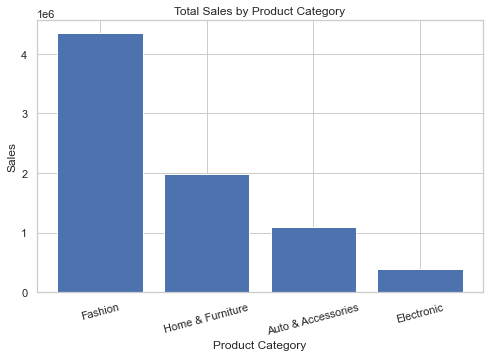

In [28]:
category_sales = (
    df.groupby("Product_Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.bar(category_sales.index,
        category_sales.values)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")

plt.xticks(rotation=15)

plt.show()

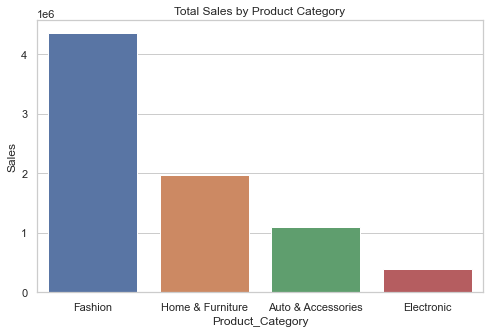

In [ ]:
category_sales = (
    df.groupby("Product_Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales,
    x="Product_Category",
    y="Sales"
)

plt.title("Total Sales by Product Category")

plt.show()

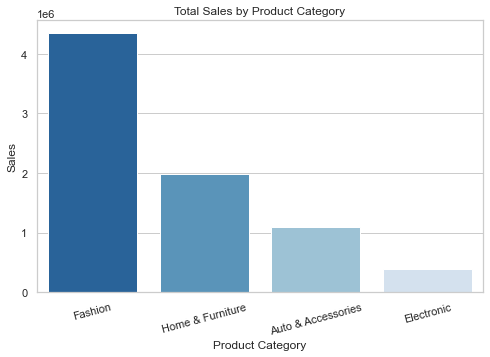

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales,
    x="Product_Category",
    y="Sales",
    palette="Blues_r"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales")
plt.xticks(rotation=15)

plt.show()


### Insight

Fashion generated the highest total sales, followed by Home & Furniture.
Electronics contributed the lowest sales volume among all product categories.